In [1]:
# Colab cell 1: Install dependencies
!pip install -q ultralytics tensorflow opencv-python-headless pillow

# (Optional) If you need a specific TF/Keras version, change above.
# Note: in some Colab runtimes TF is preinstalled; adjust versions if needed.


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 20.7 MB/s eta 0:00:00


In [2]:
# Colab cell 2: imports and configuration
import os
import cv2
import numpy as np
from PIL import Image
from ultralytics import YOLO
import tensorflow as tf
from tensorflow.keras.models import load_model

# Configuration - change these paths after uploading your models to Colab / Drive
CNN_MODEL_PATH = "/content/model_Final_pcb3.keras"      # <-- upload this
YOLO_MODEL_PATH = "/content/best_1.pt"    # <-- upload this

# Image / model settings
IMAGE_SIZE = (256, 256)   # CNN expected input (H,W)
YOLO_INIT_CONF = 0.25     # initial YOLO confidence threshold
YOLO_RECHECK_CONF = 0.15  # YOLO recheck threshold (lower for sensitive pass)

# Decision class names: adjust according to how your CNN and YOLO were trained
CORRECT_CLASS_NAME = "corrected_components"   # example
DEFECT_CLASS_NAMES = [
    "defected_r8",
    "glue_defect",
    "shift_br1",
    "shift_ic1",
    "shift_ic2",
    "shifted_resister",
    "upsidedown",

    # manual generic defect labels
    "defect",
    "missing",
    "wrong_component",
    "misaligned"
]
 # example

# Device info
print("TensorFlow version:", tf.__version__)


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
TensorFlow version: 2.20.0


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
# Colab cell 3: Upload model files
# Option A: Use Colab file upload (interactive) - recommended for one-off testing
from google.colab import files
# Run these only if you want to interactively upload files from your local machine:
uploaded = files.upload()
# After upload, move files to desired paths or rename.

# Option B: Mount Google Drive (recommended if models are large / persistent)

# files.mount('/content/drive')
# If your model is in Drive, set paths like:
# CNN_MODEL_PATH = "/content/drive/MyDrive/path/to/cnn_model.h5"

print("Now ensure CNN_MODEL_PATH and YOLO_MODEL_PATH point to the uploaded files.")

Saving best_1.pt to best_1.pt
Saving model_Final_pcb3.keras to model_Final_pcb3.keras
Now ensure CNN_MODEL_PATH and YOLO_MODEL_PATH point to the uploaded files.


In [6]:
CNN_MODEL_PATH ="/content/model_Final_pcb3.keras"

In [7]:
YOLO_MODEL_PATH = "/content/best_1.pt"


In [8]:
# Colab cell 4: Load the models (CNN first, then YOLO)
assert os.path.exists(CNN_MODEL_PATH), f"Missing CNN model at {CNN_MODEL_PATH}"
assert os.path.exists(YOLO_MODEL_PATH), f"Missing YOLO model at {YOLO_MODEL_PATH}"


print("Loading CNN model...")
cnn_model = load_model(CNN_MODEL_PATH)
print("CNN loaded.")

print("Loading YOLO model...")
yolo_model = YOLO(YOLO_MODEL_PATH)
print("YOLO loaded.")






Loading CNN model...
CNN loaded.
Loading YOLO model...
YOLO loaded.


In [9]:
# Colab cell 5: Cropping function (4 quadrants + center strip)
def crop_into_parts(img, center_strip_height_ratio=0.3):
    """
    img: numpy array (BGR)
    returns: list of parts as numpy arrays in order [top_left, top_right, bottom_left, bottom_right, center_strip]
    """
    h, w = img.shape[:2]
    # center strip parameters
    ch = int(h * center_strip_height_ratio)
    center_y1 = max((h - ch)//2, 0)
    center_y2 = min(center_y1 + ch, h)

    mid_x = w // 2
    mid_y = h // 2

    top_left = img[0:mid_y, 0:mid_x].copy()
    top_right = img[0:mid_y, mid_x:w].copy()
    bottom_left = img[mid_y:h, 0:mid_x].copy()
    bottom_right = img[mid_y:h, mid_x:w].copy()
    center_strip = img[center_y1:center_y2, 0:w].copy()

    return [top_left, top_right, bottom_left, bottom_right, center_strip]


In [10]:
# Colab cell 6: Preprocess and CNN prediction function
def preprocess_for_cnn(part_img_bgr, target_size=IMAGE_SIZE):
    # Convert BGR->RGB, resize, scale to [0,1], expand dims
    img_rgb = cv2.cvtColor(part_img_bgr, cv2.COLOR_BGR2RGB)
    img_pil = Image.fromarray(img_rgb).resize((target_size[1], target_size[0])) # PIL size is (W,H)
    arr = np.asarray(img_pil).astype(np.float32) / 255.0
    if arr.ndim == 2: # grayscale -> convert to 3 channels
        arr = np.stack([arr]*3, axis=-1)
    arr = np.expand_dims(arr, axis=0)  # batch dim
    return arr

def predict_cnn_on_part(cnn_model, part_img_bgr):
    x = preprocess_for_cnn(part_img_bgr)
    preds = cnn_model.predict(x, verbose=0)
    # Interpret preds depending on your model's final activation
    # Here we assume binary classification with softmax or sigmoid:
    if preds.shape[-1] == 1:
        # sigmoid -> single probability of defect (example)
        prob = float(preds[0][0])
        label = "defect" if prob > 0.5 else CORRECT_CLASS_NAME
        return {"label": label, "score": prob}
    else:
        # softmax multi-class
        class_idx = int(np.argmax(preds[0]))
        score = float(np.max(preds[0]))
        # map idx to names if you have class_names array
        # Example placeholder mapping:
        class_names = [CORRECT_CLASS_NAME] + DEFECT_CLASS_NAMES  # change as required
        class_names = class_names[:preds.shape[-1]]
        label = class_names[class_idx] if class_idx < len(class_names) else f"class_{class_idx}"
        return {"label": label, "score": score}


In [11]:
# Colab cell 7: YOLO prediction helper (returns list of detections)
def predict_yolo(yolo_model, img_bgr, conf=YOLO_INIT_CONF):
    """
    returns detections list with fields: (xyxy, confidence, class_name)
    """
    # ultralytics accepts BGR arrays via numpy or paths
    results = yolo_model.predict(source=img_bgr, conf=conf, verbose=False)
    # results is a list of Results (one per image). We passed 1 image only.
    r = results[0]
    detections = []
    # r.boxes.xyxy, r.boxes.conf, r.boxes.cls
    boxes = getattr(r, 'boxes', None)
    if boxes is None or len(boxes) == 0:
        return detections
    for box in boxes:
        xyxy = box.xyxy[0].cpu().numpy().tolist()   # [x1,y1,x2,y2]
        conf_score = float(box.conf[0].cpu().numpy())
        cls_id = int(box.cls[0].cpu().numpy())
        # derive class name from model's metadata if present
        try:
            cls_name = r.names[cls_id]
        except Exception:
            cls_name = f"class_{cls_id}"
        detections.append({"xyxy": xyxy, "conf": conf_score, "class": cls_name})
    return detections


In [12]:
# Colab cell 8: Combine YOLO + CNN logic per your pipeline
def process_pcb(image_path, cnn_model, yolo_model,
                yolo_init_conf=YOLO_INIT_CONF, yolo_recheck_conf=YOLO_RECHECK_CONF,
                debug=False):
    """
    Returns result dict with per-part CNN predictions, YOLO detections,
    and final verdict: 'GOOD' or 'DEFECTIVE'
    """
    if not os.path.exists(image_path):
        raise FileNotFoundError(image_path)
    img_bgr = cv2.imread(image_path)
    if img_bgr is None:
        raise ValueError("Failed to read image: " + image_path)

    result = {
        "image_path": image_path,
        "yolo_init_detections": [],
        "cnn_part_predictions": [],
        "yolo_recheck_detections": [],
        "final_verdict": None
    }

    # 1) YOLO initial pass (quick check)
    yolo_init = predict_yolo(yolo_model, img_bgr, conf=yolo_init_conf)
    result["yolo_init_detections"] = yolo_init
    if debug: print("YOLO initial detections:", yolo_init)
    # If any YOLO detection belongs to defect classes -> immediate defect
    for d in yolo_init:
        if d["class"] in DEFECT_CLASS_NAMES or d["class"].lower() in ("defect","defective","missing","wrong_component"):
            result["final_verdict"] = "DEFECTIVE"
            if debug: print("Immediate defect => YOLO initial detected", d)
            return result  # short-circuit: defect found

    # 2) Crop image into 5 parts and run CNN on each
    parts = crop_into_parts(img_bgr, center_strip_height_ratio=0.3)
    part_names = ["top_left","top_right","bottom_left","bottom_right","center_strip"]
    for name, part_img in zip(part_names, parts):
        pred = predict_cnn_on_part(cnn_model, part_img)
        pred["part"] = name
        result["cnn_part_predictions"].append(pred)
        if debug: print(f"CNN {name} ->", pred)
        # if any CNN says defect -> final defect (we can optionally mark threshold)
        if pred["label"] != CORRECT_CLASS_NAME and pred["label"].lower() != "correct":
            result["final_verdict"] = "DEFECTIVE"
            if debug: print("Defect found by CNN in", name, pred)
            # continue to accumulate info or return early; here we go to recheck logic below
            # break   # optionally break to skip remaining parts

    # 3) If no defect found so far, do a YOLO recheck with lower confidence (sensitive pass)
    if result["final_verdict"] is None:
        yolo_recheck = predict_yolo(yolo_model, img_bgr, conf=yolo_recheck_conf)
        result["yolo_recheck_detections"] = yolo_recheck
        if debug: print("YOLO recheck detections:", yolo_recheck)
        for d in yolo_recheck:
            if d["class"] in DEFECT_CLASS_NAMES or d["class"].lower() in ("defect","defective","missing","wrong_component"):
                result["final_verdict"] = "DEFECTIVE"
                if debug: print("Defect found by YOLO recheck", d)
                return result

    # 4) If neither YOLO nor CNN found defects:
    if result["final_verdict"] is None:
        result["final_verdict"] = "GOOD"
    return result


In [14]:
# Colab cell 9: Run the inspector on a sample image
sample_image_path = "/content/missing.jpg"   # <-- upload your test PCB image or set drive path
assert os.path.exists(sample_image_path), f"Place sample image at {sample_image_path}"

res = process_pcb(sample_image_path, cnn_model, yolo_model, debug=True)

# Print readable summary
print("\n==== Inspection Summary ====")
print("Image:", res["image_path"])
print("YOLO initial detections:", res["yolo_init_detections"])
print("CNN per-part predictions:")
for p in res["cnn_part_predictions"]:
    print(" ", p["part"], "->", p["label"], f"(score={p['score']:.3f})")
print("YOLO recheck detections:", res.get("yolo_recheck_detections", []))
print("FINAL RESULT:", res["final_verdict"])


YOLO initial detections: [{'xyxy': [1224.1094970703125, 2329.002685546875, 1323.1441650390625, 2540.216796875], 'conf': 0.6249819993972778, 'class': 'defected_r8'}, {'xyxy': [110.53413391113281, 1028.559814453125, 213.60154724121094, 1154.34619140625], 'conf': 0.4516989588737488, 'class': 'corrected_components'}, {'xyxy': [897.8139038085938, 1494.0450439453125, 1106.6185302734375, 1592.7313232421875], 'conf': 0.36492517590522766, 'class': 'corrected_components'}, {'xyxy': [708.2933349609375, 578.8787841796875, 936.8038330078125, 653.45263671875], 'conf': 0.3192567229270935, 'class': 'corrected_components'}, {'xyxy': [1125.2315673828125, 353.3618469238281, 1435.610595703125, 523.058837890625], 'conf': 0.3175560534000397, 'class': 'corrected_components'}, {'xyxy': [898.1982421875, 1726.2310791015625, 1107.53271484375, 1811.9384765625], 'conf': 0.3155779540538788, 'class': 'corrected_components'}, {'xyxy': [1235.3277587890625, 2023.362548828125, 1322.7855224609375, 2220.18359375], 'conf':

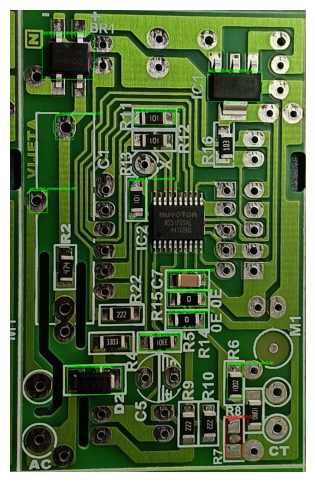

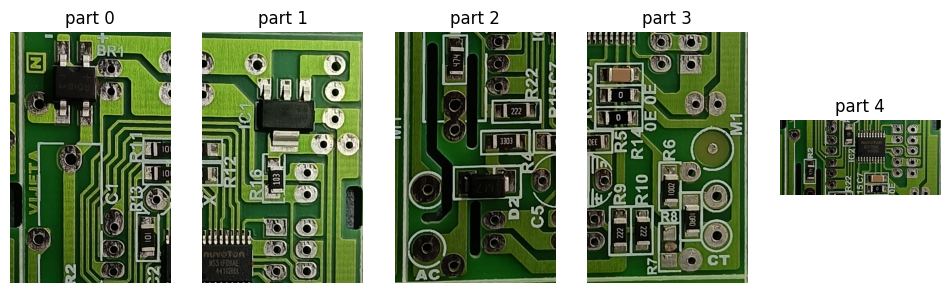

In [15]:
# Colab cell 10: Visualization helper (draw boxes from YOLO and show parts)
import matplotlib.pyplot as plt

def draw_yolo_boxes_and_show(img_path, yolo_detections):
    img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)

    for d in yolo_detections:
        x1, y1, x2, y2 = map(int, d["xyxy"])
        cls = d["class"]
        conf = d["conf"]

        # =========================
        # COLOR LOGIC ADDED HERE
        # =========================
        if cls == "corrected_components":
            color = (0, 255, 0)      # GREEN
        else:
            color = (255, 0, 0)      # RED
        # =========================

        # Draw box
        cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)

        # Draw label
        cv2.putText(
            img,
            f"{cls}:{conf:.2f}",
            (x1, max(0, y1 - 5)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            color,
            2
        )

    plt.figure(figsize=(10, 6))
    plt.imshow(img)
    plt.axis('off')


# visualize initial detections and the parts
draw_yolo_boxes_and_show(sample_image_path, res['yolo_init_detections'])

# Show the cropped parts (unchanged)
parts = crop_into_parts(cv2.imread(sample_image_path))
plt.figure(figsize=(12, 6))
for i, p in enumerate(parts):
    plt.subplot(1, 5, i + 1)
    plt.imshow(cv2.cvtColor(p, cv2.COLOR_BGR2RGB))
    plt.title(f"part {i}")
    plt.axis('off')



In [16]:
# ------------------------- Cell A -------------------------
# Flask UI (paste this at the bottom of your notebook)
!pip install -q flask==2.2.5 pyngrok==5.2.1 opencv-python-headless pillow

import os, io, tempfile, base64, json, threading, time
from flask import Flask, request, render_template_string
from pyngrok import ngrok
from PIL import Image
import cv2
import numpy as np

# ---------- HTML template ----------
HTML = """
<!DOCTYPE html>
<html lang="en">

<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <meta name="description"
        content="Professional PCB Quality Inspection System - Advanced AI-powered circuit board analysis">
    <meta name="keywords" content="PCB, inspection, quality control, AI, YOLO, CNN">
    <title>PCB Quality Inspector | Professional Circuit Board Analysis</title>
    <link href="https://fonts.googleapis.com/css2?family=Inter:wght@300;400;500;600;700&display=swap" rel="stylesheet">
    <link href="https://cdnjs.cloudflare.com/ajax/libs/font-awesome/6.4.0/css/all.min.css" rel="stylesheet">
    <style>
        :root {
            --primary-color: #0969da;
            --primary-dark: #0550ae;
            --secondary-color: #656d76;
            --success-color: #1a7f37;
            --error-color: #cf222e;
            --warning-color: #bf8700;
            --background-color: #f6f8fa;
            --surface-color: #ffffff;
            --surface-secondary: #f6f8fa;
            --text-primary: #1f2328;
            --text-secondary: #656d76;
            --text-muted: #8c959f;
            --border-color: #d1d9e0;
            --border-muted: #d8dee4;
            --shadow-sm: 0 1px 2px rgba(31, 35, 40, 0.04);
            --shadow-md: 0 3px 6px rgba(140, 149, 159, 0.15);
            --shadow-lg: 0 8px 24px rgba(140, 149, 159, 0.2);
            --radius-sm: 6px;
            --radius-md: 8px;
            --radius-lg: 12px;
        }

        * {
            margin: 0;
            padding: 0;
            box-sizing: border-box;
        }

        body {
            font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', 'Noto Sans', Helvetica, Arial, sans-serif;
            background: var(--background-color);
            color: var(--text-primary);
            line-height: 1.5;
            font-size: 14px;
            min-height: 100vh;
        }

        .container {
            max-width: 1200px;
            margin: 0 auto;
            padding: 24px;
        }

        .header {
            margin-bottom: 32px;
            padding-bottom: 16px;
            border-bottom: 1px solid var(--border-color);
        }

        .header h1 {
            font-size: 32px;
            font-weight: 600;
            color: var(--text-primary);
            margin-bottom: 4px;
            display: flex;
            align-items: center;
            gap: 12px;
        }

        .header h1 i {
            color: var(--primary-color);
            font-size: 28px;
        }

        .header .subtitle {
            font-size: 16px;
            color: var(--text-secondary);
            font-weight: 400;
        }

        .form-section {
            background: var(--surface-color);
            padding: 24px;
            border-radius: var(--radius-md);
            border: 1px solid var(--border-color);
            margin-bottom: 24px;
        }

        .form-title {
            font-size: 20px;
            font-weight: 600;
            color: var(--text-primary);
            margin-bottom: 20px;
            display: flex;
            align-items: center;
            gap: 8px;
        }

        .form-title i {
            color: var(--text-secondary);
            font-size: 16px;
        }

        .form-grid {
            display: grid;
            grid-template-columns: repeat(auto-fit, minmax(200px, 1fr));
            gap: 16px;
            margin-bottom: 20px;
        }

        .form-group {
            display: flex;
            flex-direction: column;
        }

        .form-group label {
            font-weight: 500;
            color: var(--text-primary);
            margin-bottom: 6px;
            font-size: 14px;
            display: flex;
            align-items: center;
            gap: 6px;
        }

        .form-group label i {
            color: var(--text-secondary);
            font-size: 12px;
        }

        .form-group input {
            padding: 8px 12px;
            border: 1px solid var(--border-color);
            border-radius: var(--radius-sm);
            font-size: 14px;
            transition: all 0.15s ease;
            background: var(--surface-color);
        }

        .form-group input:focus {
            outline: none;
            border-color: var(--primary-color);
            box-shadow: 0 0 0 3px rgba(9, 105, 218, 0.12);
        }

        .file-input-wrapper {
            position: relative;
            display: inline-block;
            width: 100%;
        }

        .file-input {
            position: absolute;
            opacity: 0;
            width: 100%;
            height: 100%;
            cursor: pointer;
        }

        .file-input-display {
            display: flex;
            align-items: center;
            justify-content: center;
            padding: 32px 16px;
            border: 2px dashed var(--border-muted);
            border-radius: var(--radius-md);
            background: var(--surface-secondary);
            transition: all 0.15s ease;
            cursor: pointer;
            text-align: center;
        }

        .file-input-display:hover {
            border-color: var(--primary-color);
            background: var(--surface-color);
        }

        .btn {
            background: var(--primary-color);
            color: white;
            padding: 10px 20px;
            border: none;
            border-radius: var(--radius-sm);
            font-size: 14px;
            font-weight: 500;
            cursor: pointer;
            transition: all 0.15s ease;
            display: inline-flex;
            align-items: center;
            gap: 8px;
        }

        .btn:hover {
            background: var(--primary-dark);
        }

        .btn:active {
            transform: scale(0.98);
        }

        .results-section {
            margin-top: 24px;
        }

        .wrap {
            display: grid;
            grid-template-columns: 1fr 1fr;
            gap: 24px;
            margin-top: 16px;
        }

        .col {
            background: var(--surface-color);
            padding: 20px;
            border-radius: var(--radius-md);
            border: 1px solid var(--border-color);
        }

        .col h3 {
            font-size: 18px;
            font-weight: 600;
            color: var(--text-primary);
            margin-bottom: 16px;
            padding-bottom: 8px;
            border-bottom: 1px solid var(--border-color);
            display: flex;
            align-items: center;
            gap: 8px;
        }

        .col h3 i {
            color: var(--text-secondary);
            font-size: 16px;
        }

        .parts {
            display: grid;
            grid-template-columns: repeat(auto-fit, minmax(120px, 1fr));
            gap: 12px;
            margin-top: 12px;
        }

        .part {
            text-align: center;
            padding: 12px;
            background: var(--surface-secondary);
            border-radius: var(--radius-sm);
            border: 1px solid var(--border-muted);
        }

        .part img {
            width: 100%;
            height: auto;
            border-radius: 4px;
            margin-bottom: 8px;
        }

        img {
            max-width: 100%;
            height: auto;
            border-radius: var(--radius-sm);
            border: 1px solid var(--border-muted);
        }

        pre {
            background: #0d1117;
            color: #7c3aed;
            padding: 16px;
            border-radius: var(--radius-sm);
            overflow: auto;
            max-height: 300px;
            font-family: 'SF Mono', Monaco, 'Cascadia Code', 'Roboto Mono', Consolas, monospace;
            font-size: 12px;
            line-height: 1.45;
            border: 1px solid #21262d;
        }

        .verdict-good {
            background: #dafbe1;
            color: var(--success-color);
            padding: 12px 16px;
            border-radius: var(--radius-sm);
            font-weight: 500;
            border: 1px solid #aceeba;
            display: flex;
            align-items: center;
            gap: 8px;
            font-size: 14px;
        }

        .verdict-bad {
            background: #ffebe9;
            color: var(--error-color);
            padding: 12px 16px;
            border-radius: var(--radius-sm);
            font-weight: 500;
            border: 1px solid #ffbdad;
            display: flex;
            align-items: center;
            gap: 8px;
            font-size: 14px;
        }

        .small {
            font-size: 12px;
            color: var(--text-secondary);
            font-weight: 400;
        }

        .footer {
            text-align: center;
            margin-top: 48px;
            padding: 24px;
            border-top: 1px solid var(--border-color);
        }

        .divider {
            height: 1px;
            background: var(--border-color);
            margin: 32px 0;
        }

        @media (max-width: 768px) {
            .container {
                padding: 16px;
            }

            .wrap {
                grid-template-columns: 1fr;
                gap: 16px;
            }

            .form-grid {
                grid-template-columns: 1fr;
            }

            .header h1 {
                font-size: 24px;
            }

            .col {
                padding: 16px;
            }
        }

        .loading {
            display: none;
            text-align: center;
            padding: 2rem;
        }

        .spinner {
            border: 3px solid var(--border-color);
            border-top: 3px solid var(--primary-color);
            border-radius: 50%;
            width: 40px;
            height: 40px;
            animation: spin 1s linear infinite;
            margin: 0 auto 1rem;
        }

        @keyframes spin {
            0% {
                transform: rotate(0deg);
            }

            100% {
                transform: rotate(360deg);
            }
        }
    </style>
</head>

<body>
    <div class="container">
        <header class="header">
            <h1>
                <i class="fas fa-microchip"></i>
                PCB Quality Inspector
            </h1>
            <p class="subtitle">Professional Circuit Board Analysis & Quality Control System</p>
        </header>

        <section class="form-section">
            <h2 class="form-title">
                <i class="fas fa-upload"></i>
                Upload & Configure Analysis
            </h2>

            <form method="post" action="/inspect" enctype="multipart/form-data" id="inspectionForm">
                <div class="form-grid">
                    <div class="form-group">
                        <label for="image">
                            <i class="fas fa-image"></i>
                            Upload PCB Image
                        </label>
                        <div class="file-input-wrapper">
                            <input type="file" name="image" id="image" class="file-input" accept="image/*" required />
                            <div class="file-input-display">
                                <div>
                                    <i class="fas fa-cloud-upload-alt"
                                        style="font-size: 2rem; color: var(--primary-color); margin-bottom: 0.5rem;"></i>
                                    <p><strong>Click to upload</strong> or drag and drop</p>
                                    <p class="small">Supports JPG, PNG, BMP formats</p>
                                </div>
                            </div>
                        </div>
                    </div>
                </div>

                <div class="form-grid">
                    <div class="form-group">
                        <label for="yolo_init_conf">
                            <i class="fas fa-search"></i>
                            YOLO Initial Confidence
                        </label>
                        <input name="yolo_init_conf" id="yolo_init_conf" type="number" min="0.05" max="0.9" step="0.01"
                            value="0.25" />
                    </div>

                    <div class="form-group">
                        <label for="yolo_recheck_conf">
                            <i class="fas fa-redo"></i>
                            YOLO Recheck Confidence
                        </label>
                        <input name="yolo_recheck_conf" id="yolo_recheck_conf" type="number" min="0.05" max="0.9"
                            step="0.01" value="0.15" />
                    </div>

                    <div class="form-group">
                        <label for="center_strip_ratio">
                            <i class="fas fa-expand-arrows-alt"></i>
                            Center Strip Ratio
                        </label>
                        <input name="center_strip_ratio" id="center_strip_ratio" type="number" min="0.1" max="0.8"
                            step="0.05" value="0.3" />
                    </div>
                </div>

                <div style="text-align: center; margin-top: 24px;">
                    <button type="submit" class="btn">
                        <i class="fas fa-play"></i>
                        Start Quality Inspection
                    </button>
                </div>
            </form>

            <div class="loading" id="loadingIndicator">
                <div class="spinner"></div>
                <p>Processing PCB analysis... Please wait.</p>
            </div>
        </section>

        {% if results %}
        <div class="divider"></div>

        <section class="results-section">
            <div class="wrap">
                <div class="col">
                    <h3>
                        <i class="fas fa-images"></i>
                        Analysis Results
                    </h3>

                    <div style="margin-bottom: 20px;">
                        <h4 style="color: var(--text-secondary); margin-bottom: 8px; font-size: 14px; font-weight: 500;">Original Image</h4>
                        <img src="data:image/jpeg;base64,{{ results.original_b64 }}" alt="Original PCB Image" />
                    </div>

                    <div style="margin-bottom: 20px;">
                        <h4 style="color: var(--text-secondary); margin-bottom: 8px; font-size: 14px; font-weight: 500;">YOLO Initial Detection</h4>
                        {% if results.yolo_init_b64 %}
                        <img src="data:image/png;base64,{{ results.yolo_init_b64 }}" alt="YOLO Initial Detection" />
                        {% else %}
                        <div class="small"
                            style="padding: 16px; text-align: center; background: var(--surface-secondary); border-radius: var(--radius-sm); border: 1px solid var(--border-muted);">
                            <i class="fas fa-info-circle"></i> No initial detections found
                        </div>
                        {% endif %}
                    </div>

                    <div style="margin-bottom: 20px;">
                        <h4 style="color: var(--text-secondary); margin-bottom: 8px; font-size: 14px; font-weight: 500;">YOLO Recheck Detection</h4>
                        {% if results.yolo_re_b64 %}
                        <img src="data:image/png;base64,{{ results.yolo_re_b64 }}" alt="YOLO Recheck Detection" />
                        {% else %}
                        <div class="small"
                            style="padding: 16px; text-align: center; background: var(--surface-secondary); border-radius: var(--radius-sm); border: 1px solid var(--border-muted);">
                            <i class="fas fa-info-circle"></i> No recheck detections found
                        </div>
                        {% endif %}
                    </div>

                    <div>
                        <h4 style="color: var(--text-secondary); margin-bottom: 8px; font-size: 14px; font-weight: 500;">Quality Assessment</h4>
                        {% if results.final_verdict == "GOOD" %}
                        <div class="verdict-good">
                            <i class="fas fa-check-circle"></i>
                            PCB Quality: PASSED
                        </div>
                        {% elif results.final_verdict == "DEFECTIVE" %}
                        <div class="verdict-bad">
                            <i class="fas fa-times-circle"></i>
                            PCB Quality: FAILED
                        </div>
                        {% else %}
                        <div class="small"
                            style="padding: 12px; background: var(--surface-secondary); border-radius: var(--radius-sm); border: 1px solid var(--border-color);">
                            <i class="fas fa-question-circle"></i>
                            Assessment Result: {{ results.final_verdict }}
                        </div>
                        {% endif %}
                    </div>
                </div>

                <div class="col">
                    <h3>
                        <i class="fas fa-cogs"></i>
                        Component Analysis
                    </h3>

                    <div class="parts">
                        {% for p in results.parts %}
                        <div class="part">
                            <img src="data:image/jpeg;base64,{{ p.img_b64 }}" alt="Component {{ p.name }}" />
                            <div style="margin-top: 6px;">
                                <div style="font-weight: 500; color: var(--text-primary); font-size: 12px;">{{ p.name }}</div>
                                <div class="small">{{ p.label }}</div>
                                <div class="small">{{ '%.1f'|format(p.score * 100) }}%</div>
                            </div>
                        </div>
                        {% endfor %}
                    </div>

                    <div style="margin-top: 20px;">
                        <h4 style="color: var(--text-secondary); margin-bottom: 8px; font-size: 14px; font-weight: 500; display: flex; align-items: center; gap: 6px;">
                            <i class="fas fa-code"></i>
                            Technical Details
                        </h4>
                        <pre>{{ results.raw_json }}</pre>
                    </div>
                </div>
            </div>
        </section>
        {% endif %}

        <footer class="footer">
            <p class="small">
                <i class="fas fa-flask"></i>
                Professional PCB Quality Control System | Powered by Advanced AI & Machine Learning
            </p>
            <p class="small" style="margin-top: 0.5rem; opacity: 0.7;">
                This application integrates YOLO object detection and CNN classification for comprehensive circuit board
                analysis
            </p>
        </footer>
    </div>

    <script>
        // Enhanced form interaction
        document.getElementById('inspectionForm').addEventListener('submit', function () {
            document.getElementById('loadingIndicator').style.display = 'block';
        });

        // File input enhancement
        const fileInput = document.getElementById('image');
        const fileDisplay = document.querySelector('.file-input-display');

        fileInput.addEventListener('change', function (e) {
            if (e.target.files.length > 0) {
                const fileName = e.target.files[0].name;
                fileDisplay.innerHTML = `
          <div>
            <i class="fas fa-check-circle" style="font-size: 2rem; color: var(--success-color); margin-bottom: 0.5rem;"></i>
            <p><strong>Selected:</strong> ${fileName}</p>
            <p class="small">Click to change file</p>
          </div>
        `;
            }
        });
    </script>
</body>

</html>
"""

# ---------- helpers to convert images ----------
def bgr_to_jpeg_b64(img_bgr, fmt="jpeg", quality=90):
    rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    pil = Image.fromarray(rgb)
    buff = io.BytesIO()
    pil.save(buff, format=fmt.upper(), quality=quality)
    return base64.b64encode(buff.getvalue()).decode("ascii")

def draw_yolo_boxes(img_bgr, detections):
    img = img_bgr.copy()
    for d in detections:
        try:
            x1, y1, x2, y2 = map(int, d["xyxy"])
            lbl = f"{d['class']}:{d['conf']:.2f}"

            # =========================
            # COLOR LOGIC (your rule)
            # =========================
            if d["class"] == "corrected_components":
                color = (0, 255, 0)   # GREEN
            else:
                color = (0, 0, 255)   # RED
            # =========================

            cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
            cv2.putText(img, lbl, (x1, max(0, y1 - 5)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1)

        except Exception:
            continue

    return img


# ---------- Flask app using your in-memory functions ----------
app = Flask(__name__)

@app.route("/", methods=["GET"])
def index():
    return render_template_string(HTML)

@app.route("/inspect", methods=["POST"])
def inspect():
    # save upload
    f = request.files.get("image")
    if f is None:
        return "No file", 400
    tmpdir = tempfile.mkdtemp()
    img_path = os.path.join(tmpdir, f.filename)
    f.save(img_path)

    # parse params
    try:
        yi = float(request.form.get("yolo_init_conf", 0.25))
        yr = float(request.form.get("yolo_recheck_conf", 0.15))
        cs = float(request.form.get("center_strip_ratio", 0.3))
    except Exception:
        yi, yr, cs = 0.25, 0.15, 0.3

    # ---------- USE your in-memory models / functions ----------
    # If you used getter functions instead, uncomment the next two lines and comment the direct variable usage:
    # cnn = get_cnn()   # uncomment if you have get_cnn()
    # yolo = get_yolo() # uncomment if you have get_yolo()

    # Direct usage assumes 'cnn_model' and 'yolo_model' variables exist in notebook:
    try:
        cnn = cnn_model
        yolo = yolo_model
    except NameError:
        return "<h3>Error: 'cnn_model' or 'yolo_model' not found in notebook namespace.</h3>", 500

    # Call your process_pcb function (must be present in the notebook)
    try:
        res = process_pcb(img_path, cnn, yolo, yolo_init_conf=yi, yolo_recheck_conf=yr, debug=False)
    except Exception as e:
        return f"<h3>Pipeline threw an exception:</h3><pre>{str(e)}</pre>", 500

    # Prepare images
    orig_bgr = cv2.imread(img_path)
    original_b64 = bgr_to_jpeg_b64(orig_bgr, fmt="jpeg")

    yolo_init = res.get("yolo_init_detections", [])
    yolo_re = res.get("yolo_recheck_detections", [])

    y_init_b64 = None
    if yolo_init:
        vis = draw_yolo_boxes(orig_bgr, yolo_init)
        y_init_b64 = bgr_to_jpeg_b64(vis, fmt="png")

    y_re_b64 = None
    if yolo_re:
        vis2 = draw_yolo_boxes(orig_bgr, yolo_re)
        y_re_b64 = bgr_to_jpeg_b64(vis2, fmt="png")

    # crop parts using your crop_into_parts
    try:
        parts_imgs = crop_into_parts(orig_bgr, center_strip_height_ratio=cs)
    except Exception as e:
        return f"<h3>crop_into_parts not available or errored: {e}</h3>", 500

    part_names = ["Top-Left","Top-Right","Bottom-Left","Bottom-Right","Center"]
    cnn_preds = res.get("cnn_part_predictions", [])
    parts_payload = []
    for i, pimg in enumerate(parts_imgs):
        b64 = bgr_to_jpeg_b64(pimg, fmt="jpeg")
        pred = cnn_preds[i] if i < len(cnn_preds) else {"label":"N/A","score":0.0}
        parts_payload.append({"name": part_names[i] if i < len(part_names) else f"part_{i}",
                              "img_b64": b64, "label": pred.get("label","N/A"), "score": float(pred.get("score",0.0))})

    results = {
        "original_b64": original_b64,
        "yolo_init_b64": y_init_b64,
        "yolo_re_b64": y_re_b64,
        "final_verdict": res.get("final_verdict","UNKNOWN"),
        "parts": parts_payload,
        "raw_json": json.dumps(res, indent=2, default=str)
    }

    return render_template_string(HTML, results=results)

# Expose objects so the notebook can control the server thread
flask_app = app
print("Flask app defined. Ready to start in the next cell.")
# ------------------------- End Cell A -------------------------


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 761.3/761.3 kB 11.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.8/101.8 kB 5.7 MB/s eta 0:00:00
Flask app defined. Ready to start in the next cell.


In [17]:
# ------------------ Cell 2: Start Flask server in background ------------------
import threading, time

def run_flask():
    # Note: use_reloader=False so thread doesn't spawn duplicate processes
    flask_app.run(host="0.0.0.0", port=5000, debug=False, use_reloader=False)

thread = threading.Thread(target=run_flask, daemon=True)
thread.start()
time.sleep(1.5)
print("Flask started on port 5000. If you see errors, check the Colab logs above.")
# ------------------ End Cell 2 ------------------


 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on all addresses (0.0.0.0)
 * Running on http://127.0.0.1:5000
 * Running on http://172.28.0.12:5000
INFO:werkzeug:Press CTRL+C to quit


Flask started on port 5000. If you see errors, check the Colab logs above.


In [18]:
# Cell 3a: install localtunnel (may take a moment)
!npm install -g localtunnel


⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦
added 22 packages in 3s
⠧
⠧3 packages are looking for funding
⠧  run `npm fund` for details
⠧

In [19]:
# ------------------ Cell 3: install node/npm if needed, install localtunnel, start tunnel ------------------
# Pick a short custom subdomain (letters/numbers/hyphen). Change it below.
import random # Import the random module
SUBDOMAIN = "pcbinspect" + str(random.randint(100,999))  # change to e.g. "pcbayush" if you prefer

# 1) ensure node & npm exist (install minimal Node if missing)
import shutil, subprocess, time, sys, os, re
if shutil.which("node") is None or shutil.which("npm") is None:
    print("Installing nodejs & npm (apt-get)... this may take ~20-30s")
    !apt-get update -qq
    !apt-get install -y -qq nodejs npm
else:
    print("node & npm already present.")

# 2) install localtunnel globally (if not available)
if shutil.which("lt") is None:
    print("Installing localtunnel (npm)...")
    !npm install -g localtunnel
else:
    print("localtunnel (lt) already installed.")

# 3) Try to start localtunnel using subprocess and custom subdomain.
# We'll try a few subdomain attempts if the first is taken.
max_attempts = 4
attempt = 0
lt_proc = None
public_url = None

while attempt < max_attempts and public_url is None:
    attempt += 1
    sub = SUBDOMAIN if attempt == 1 else f"{SUBDOMAIN}{attempt}"
    print(f"Attempt {attempt}: trying subdomain = {sub}")
    # use npx lt if 'lt' binary not found; otherwise use lt
    cmd = ["npx", "localtunnel", "--port", "5000", "--subdomain", sub] if shutil.which("lt") is None else ["lt", "--port", "5000", "--subdomain", sub]
    # run in background and capture stdout
    try:
        lt_proc = subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)
    except Exception as e:
        print("Failed to start localtunnel process:", e)
        break

    # wait up to 8 seconds for output
    start = time.time()
    while time.time() - start < 8:
        line = lt_proc.stdout.readline()
        if not line:
            time.sleep(0.1)
            continue
        print("lt:", line.strip())
        # localtunnel prints a line like: your url is: https://<subdomain>.loca.lt
        m = re.search(r"https?://[^\s]+", line)
        if m:
            public_url = m.group(0).strip()
            break

    if public_url:
        print("✔ LocalTunnel public URL:", public_url)
        print("Open it in your browser. The app endpoint is:", public_url)
        break
    else:
        # if process is still running and no url, kill and retry with another subdomain
        try:
            lt_proc.kill()
        except:
            pass
        lt_proc = None
        print("No URL from localtunnel for subdomain", sub, "- trying another subdomain...")

if public_url is None:
    print("Failed to create localtunnel after attempts. Inspect process logs or try a different SUBDOMAIN manually.")
else:
    # keep lt_proc reference so tunnel stays up; save it to globals for later control
    GLOBAL_LT_PROC = lt_proc
    GLOBAL_LT_URL = public_url
    print("Tunnel running in background. To stop it, run: GLOBAL_LT_PROC.kill() or restart the Colab runtime.")
# ------------------ End Cell 3 ------------------


node & npm already present.
localtunnel (lt) already installed.
Attempt 1: trying subdomain = pcbinspect726
lt: your url is: https://pcbinspect726.loca.lt
✔ LocalTunnel public URL: https://pcbinspect726.loca.lt
Open it in your browser. The app endpoint is: https://pcbinspect726.loca.lt
Tunnel running in background. To stop it, run: GLOBAL_LT_PROC.kill() or restart the Colab runtime.


In [20]:
!curl -s https://loca.lt/mytunnelpassword


136.113.249.104